# Laboratorio 4 — Simulación de eventos discretos
## 5.2 Red de colas (ITV / Centro de Diagnóstico Automotriz)

Implementación basada en el notebook del curso *Red de Colas.ipynb* (Sec. 5.5.2 de Rios08). Se conservan
las cuatro rutinas de sucesos (`Llegada_cliente`, `Servicio_nodo1`, `Servicio_nodo2`, `Servicio_nodo3`) y la
lista de sucesos `TSuc`, y se reemplazan las llamadas a `numpy.random` por los generadores propios
alimentados con el GLC de módulo $2^{48}$ de los laboratorios anteriores.

**Convención de parámetros.** El notebook base genera los tiempos exponenciales con
`np.random.exponential(L)`, cuyo argumento es la *media* (escala). Para poder comparar con el ejemplo, los
parámetros $\lambda$ y $\mu_2$ de la guía se interpretan de la misma forma: media de la exponencial.

| Parámetro | Escenario A | Escenario B |
|---|---|---|
| Llegadas Exp (media $\lambda$) | 2 | 3 |
| N1: N($\mu_1,\sigma_1$) | (2.1, 0.5) | (3.0, 1.0) |
| N2: Exp (media $\mu_2$) | 2.4 | 1.5 |
| N3 si $n_3<5$: N($\mu_{31},\sigma_{31}$) | (4.1, 2.5) | (4.0, 2.0) |
| N3 si $n_3\ge5$: N($\mu_{32},\sigma_{32}$) | (3.0, 2.0) | (2.0, 1.5) |
| $T$ | 300 | 300 |

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

A, C, M_GLC = 25214903917, 11, 2**48

class GLC:
    def __init__(self, X0, a=A, c=C, m=M_GLC):
        self.X, self.a, self.c, self.m = X0, a, c, m
        self.consumidos = 0
    def uniforme(self):
        self.X = (self.a * self.X + self.c) % self.m
        self.consumidos += 1
        return self.X / self.m

def exponencial_media(g, media):
    """Exponencial por transformada inversa parametrizada por su MEDIA (como np.random.exponential)."""
    return -media * math.log(1 - g.uniforme())

_cache = {}
def normal_polar(g, mu=0.0, sigma=1.0):
    if g in _cache:
        z = _cache.pop(g)
    else:
        while True:
            v1, v2 = 2 * g.uniforme() - 1, 2 * g.uniforme() - 1
            s = v1 * v1 + v2 * v2
            if 0 < s <= 1:
                k = math.sqrt(-2 * math.log(s) / s)
                z, _cache[g] = v1 * k, v2 * k
                break
    return mu + sigma * z

def normal_truncada(g, mu, sigma):
    return max(0.0, normal_polar(g, mu, sigma))

### Modelo de la red de colas
`simular_red` recibe el diccionario de parámetros `p` y un generador `g`, y devuelve las diez medidas de
desempeño de la guía y las trayectorias $n_1(t), n_2(t), n_3(t), n(t)$.

In [2]:
ESC_A = dict(T=300.0, L=2.0, mu1=2.1, sigma1=0.5, mu2=2.4, mu31=4.1, sigma31=2.5, mu32=3.0, sigma32=2.0)
ESC_B = dict(T=300.0, L=3.0, mu1=3.0, sigma1=1.0, mu2=1.5, mu31=4.0, sigma31=2.0, mu32=2.0, sigma32=1.5)

MEDIDAS = ['t_med_sistema', 'n_med_n1', 'n_med_n2', 'n_med_n3', 'Tp', 'n_max', 'NS1', 'NS2', 'NS3', 'total']
NOMBRES = {'t_med_sistema': 'Tiempo medio de los clientes en el sistema',
           'n_med_n1': 'Número promedio de clientes en el nodo 1',
           'n_med_n2': 'Número promedio de clientes en el nodo 2',
           'n_med_n3': 'Número promedio de clientes en el nodo 3',
           'Tp': 'Tiempo desde T hasta que sale el último cliente (Tp)',
           'n_max': 'Número máximo de clientes en el sistema',
           'NS1': 'Total de clientes que pasaron por el nodo 1',
           'NS2': 'Total de clientes que pasaron por el nodo 2',
           'NS3': 'Total de clientes que pasaron por el nodo 3',
           'total': 'Total de clientes que pasaron por el sistema'}

def simular_red(p, g, M=999999.0):
    T = p['T']
    e = dict(t=0.0, n1=0, n2=0, n3=0, NLL1=0, NLL2=0, NLL3=0, NS1=0, NS2=0, NS3=0,
             n_med_n1=0.0, n_med_n2=0.0, n_med_n3=0.0)
    TSuc = {"tLL1": M, "tS1": M, "tS2": M, "tS3": M}
    LL1, LL2, LL3, S1, S2, S3 = [], [], [], [], [], []
    at, an1, an2, an3, an = [], [], [], [], []

    def servicio_n3():
        if e['n3'] < 5:
            return normal_truncada(g, p['mu31'], p['sigma31'])
        return normal_truncada(g, p['mu32'], p['sigma32'])

    def Llegada_cliente(tsuc):
        e['n_med_n1'] += e['n1'] * (tsuc - e['t']); e['n1'] += 1
        e['NLL1'] += 1; LL1.append(tsuc); e['t'] = tsuc
        Y = exponencial_media(g, p['L'])
        if e['t'] + Y < T:
            TSuc['tLL1'] = e['t'] + Y
        if e['n1'] == 1:
            TSuc['tS1'] = e['t'] + normal_truncada(g, p['mu1'], p['sigma1'])

    def Servicio_nodo1(tsuc):
        e['n_med_n1'] += e['n1'] * (tsuc - e['t']); e['n1'] -= 1
        e['NS1'] += 1; S1.append(tsuc)
        if g.uniforme() <= 0.4:                      # pruebas adicionales (vehículo antiguo)
            e['n_med_n2'] += e['n2'] * (tsuc - e['t']); e['n2'] += 1
            e['NLL2'] += 1; LL2.append(tsuc)
            if e['n2'] == 1:
                TSuc['tS2'] = tsuc + exponencial_media(g, p['mu2'])
        else:                                        # pasa directo a las pruebas estándar
            e['n_med_n3'] += e['n3'] * (tsuc - e['t']); e['n3'] += 1
            e['NLL3'] += 1; LL3.append(tsuc)
            if e['n3'] == 1:
                TSuc['tS3'] = tsuc + servicio_n3()
        e['t'] = tsuc
        if e['n1'] > 0:
            TSuc['tS1'] = tsuc + normal_truncada(g, p['mu1'], p['sigma1'])

    def Servicio_nodo2(tsuc):
        e['n_med_n2'] += e['n2'] * (tsuc - e['t']); e['n2'] -= 1
        e['NS2'] += 1; S2.append(tsuc)
        if e['n2'] > 0:
            TSuc['tS2'] = tsuc + exponencial_media(g, p['mu2'])
        e['n_med_n3'] += e['n3'] * (tsuc - e['t']); e['n3'] += 1
        e['NLL3'] += 1; LL3.append(tsuc)
        if e['n3'] == 1:
            TSuc['tS3'] = tsuc + servicio_n3()
        e['t'] = tsuc

    def Servicio_nodo3(tsuc):
        e['n_med_n3'] += e['n3'] * (tsuc - e['t']); e['n3'] -= 1
        e['NS3'] += 1; S3.append(tsuc)
        if e['n3'] > 0:
            TSuc['tS3'] = tsuc + servicio_n3()
        e['t'] = tsuc

    rutinas = {"tLL1": Llegada_cliente, "tS1": Servicio_nodo1, "tS2": Servicio_nodo2, "tS3": Servicio_nodo3}

    X = exponencial_media(g, p['L'])
    if X > T:
        return None
    Llegada_cliente(X)
    at.append(X); an1.append(e['n1']); an2.append(e['n2']); an3.append(e['n3']); an.append(e['n1'])
    while min(TSuc.values()) != M:
        clave = min(TSuc, key=TSuc.get)              # próximo suceso
        tsuc = TSuc[clave]; TSuc[clave] = M
        rutinas[clave](tsuc)
        at.append(tsuc); an1.append(e['n1']); an2.append(e['n2']); an3.append(e['n3'])
        an.append(e['n1'] + e['n2'] + e['n3'])

    Tp = max(0.0, e['t'] - T)
    ac1 = sum(S1[i] - LL1[i] for i in range(e['NLL1']))
    ac2 = sum(S2[i] - LL2[i] for i in range(e['NLL2']))
    ac3 = sum(S3[i] - LL3[i] for i in range(e['NLL3']))
    t_med = ac1 / e['NLL1'] + (0.4 * ac2 / e['NLL2'] if e['NLL2'] else 0.0) + ac3 / e['NLL3']
    return dict(t_med_sistema=t_med, n_med_n1=e['n_med_n1'] / e['t'], n_med_n2=e['n_med_n2'] / e['t'],
                n_med_n3=e['n_med_n3'] / e['t'], Tp=Tp, n_max=max(an),
                NS1=e['NS1'], NS2=e['NS2'], NS3=e['NS3'], total=e['NS3'],
                at=np.array(at), an1=np.array(an1), an2=np.array(an2), an3=np.array(an3), an=np.array(an))

def imprimir(res, titulo):
    print(f"--- {titulo} ---")
    for k in MEDIDAS:
        v = res[k]
        print(f"{NOMBRES[k]}: {v:.4f}" if isinstance(v, float) else f"{NOMBRES[k]}: {v}")

def graficar(res, titulo, T, archivo=None):
    fig, ax = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
    for a, (serie, et) in zip(ax.ravel(), [('an1', 'n1(t): ventanilla'), ('an2', 'n2(t): pruebas adicionales'),
                                            ('an3', 'n3(t): pruebas estándar'), ('an', 'n(t): sistema')]):
        a.step(res['at'], res[serie], where='post', lw=0.9); a.set_ylabel(et)
        a.axvline(T, color='gray', ls='--', lw=0.8); a.grid(alpha=0.3)
    ax[1, 0].set_xlabel('tiempo (t)'); ax[1, 1].set_xlabel('tiempo (t)')
    fig.suptitle(titulo); fig.tight_layout()
    if archivo:
        fig.savefig(archivo, dpi=150, bbox_inches='tight')
    plt.show()

### Escenario A — una ejecución

--- Escenario A ---
Tiempo medio de los clientes en el sistema: 94.2163
Número promedio de clientes en el nodo 1: 4.5700
Número promedio de clientes en el nodo 2: 0.1282
Número promedio de clientes en el nodo 3: 16.5799
Tiempo desde T hasta que sale el último cliente (Tp): 206.7261
Número máximo de clientes en el sistema: 63
Total de clientes que pasaron por el nodo 1: 163
Total de clientes que pasaron por el nodo 2: 67
Total de clientes que pasaron por el nodo 3: 163
Total de clientes que pasaron por el sistema: 163


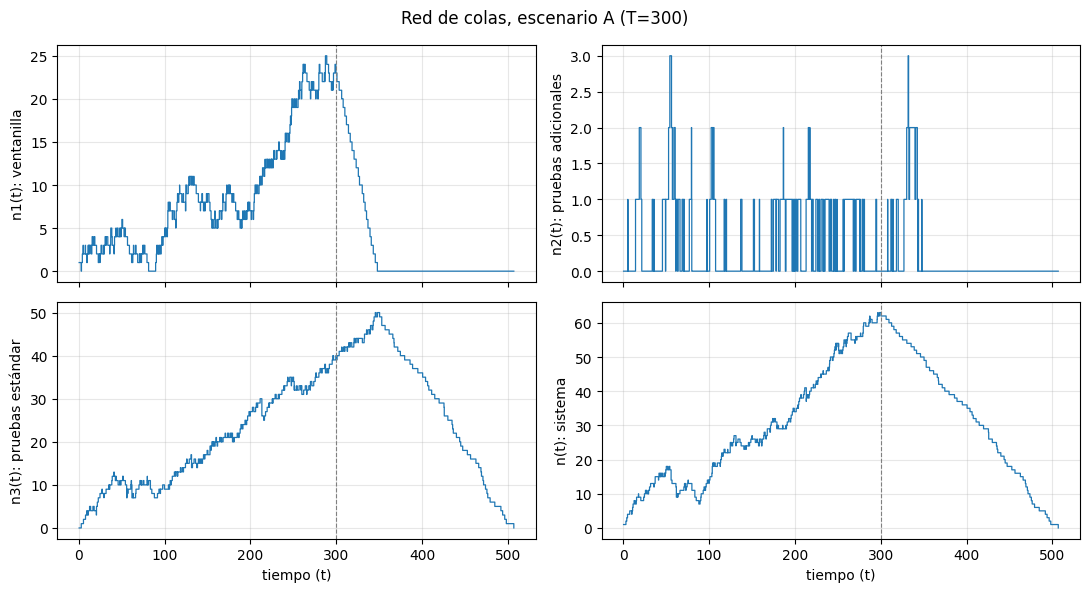

In [3]:
gA = GLC(2391)
resA = simular_red(ESC_A, gA)
imprimir(resA, 'Escenario A')
graficar(resA, 'Red de colas, escenario A (T=300)', 300, 'red_escenarioA.png')

### Escenario B — una ejecución

--- Escenario B ---
Tiempo medio de los clientes en el sistema: 46.3809
Número promedio de clientes en el nodo 1: 6.3722
Número promedio de clientes en el nodo 2: 0.0835
Número promedio de clientes en el nodo 3: 2.5986
Tiempo desde T hasta que sale el último cliente (Tp): 49.4521
Número máximo de clientes en el sistema: 24
Total de clientes que pasaron por el nodo 1: 112
Total de clientes que pasaron por el nodo 2: 45
Total de clientes que pasaron por el nodo 3: 112
Total de clientes que pasaron por el sistema: 112


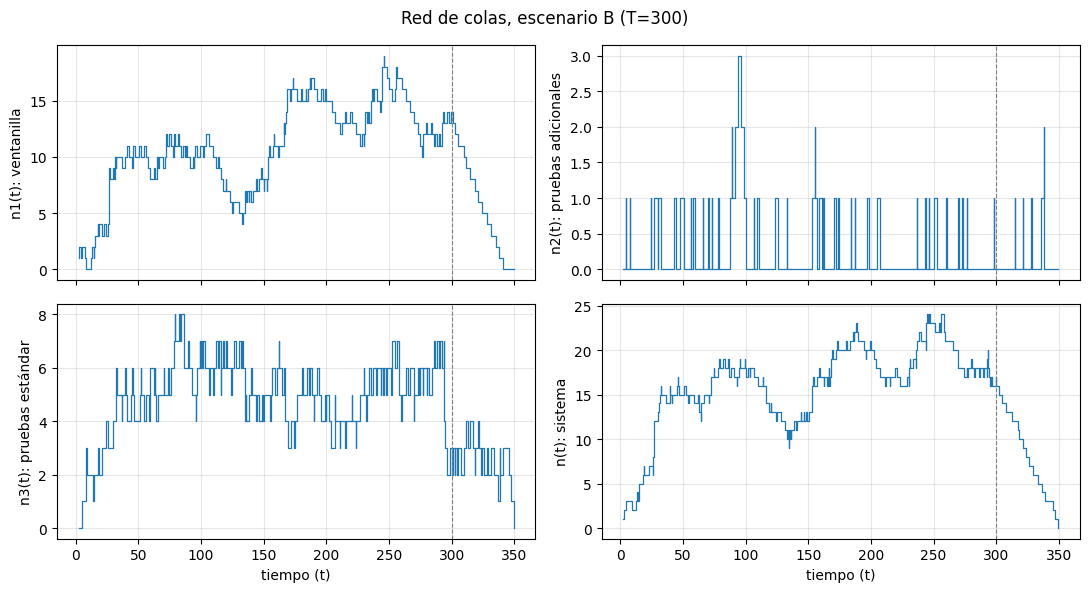

In [4]:
gB = GLC(6151)
resB = simular_red(ESC_B, gB)
imprimir(resB, 'Escenario B')
graficar(resB, 'Red de colas, escenario B (T=300)', 300, 'red_escenarioB.png')

### 20 repeticiones por escenario: media, desviación estándar e intervalo de confianza del 95 %
Para cada medida $Y$ con $n=20$ repeticiones independientes se calcula la media muestral $\bar Y$, la
desviación estándar muestral $S$ y el intervalo $\bar Y \pm t_{0{,}975;\,19}\,S/\sqrt{n}$.

In [5]:
def repetir(p, n_rep, semilla_base):
    filas = []
    for r in range(n_rep):
        g = GLC(semilla_base + 7919 * r)
        res = simular_red(p, g)
        filas.append([res[k] for k in MEDIDAS])
    return np.array(filas, dtype=float)

def resumen(rep, n_rep=20, conf=0.95):
    media = rep.mean(axis=0)
    sd = rep.std(axis=0, ddof=1)
    tq = stats.t.ppf(1 - (1 - conf) / 2, n_rep - 1)
    h = tq * sd / math.sqrt(n_rep)
    return media, sd, media - h, media + h, h

repA = repetir(ESC_A, 20, 1001)
repB = repetir(ESC_B, 20, 5001)
np.set_printoptions(suppress=True, linewidth=160)
print("Escenario A, 20 repeticiones (columnas en el orden de MEDIDAS):\n", np.round(repA, 3))
print("\nEscenario B, 20 repeticiones:\n", np.round(repB, 3))

for nombre, rep in [('A', repA), ('B', repB)]:
    media, sd, lo, hi, h = resumen(rep)
    print(f"\nTabla 2{nombre}. Escenario {nombre}: media, desviación estándar e IC 95% (n=20, t_0.975;19 = {stats.t.ppf(0.975, 19):.3f})")
    print(f"{'Medida':58s} {'Media':>10s} {'Desv. est.':>10s} {'IC 95% inf':>11s} {'IC 95% sup':>11s} {'Semiancho':>10s}")
    for j, k in enumerate(MEDIDAS):
        print(f"{NOMBRES[k]:58s} {media[j]:10.3f} {sd[j]:10.3f} {lo[j]:11.3f} {hi[j]:11.3f} {h[j]:10.3f}")

Escenario A, 20 repeticiones (columnas en el orden de MEDIDAS):
 [[ 81.149   1.685   0.128  15.793 148.082  48.    137.     52.    137.    137.   ]
 [107.118   7.86    0.186  17.821 171.114  60.    163.     64.    163.    163.   ]
 [121.77    4.75    0.193  21.207 237.138  76.    159.     67.    159.    159.   ]
 [120.839   6.186   0.133  20.923 208.795  71.    156.     55.    156.    156.   ]
 [ 58.022   2.293   0.154  10.898 118.487  42.    140.     52.    140.    140.   ]
 [ 93.719   4.924   0.163  17.04  173.748  60.    158.     62.    158.    158.   ]
 [147.867  10.262   0.347  23.448 261.335  93.    181.     76.    181.    181.   ]
 [ 95.128   2.284   0.216  18.174 156.336  51.    139.     56.    139.    139.   ]
 [ 95.893   2.999   0.177  17.497 159.308  57.    143.     59.    143.    143.   ]
 [ 91.267   2.209   0.187  16.995 160.983  50.    141.     55.    141.    141.   ]
 [ 64.585   1.166   0.133  11.607 135.445  39.    132.     55.    132.    132.   ]
 [112.547   6.841   0.

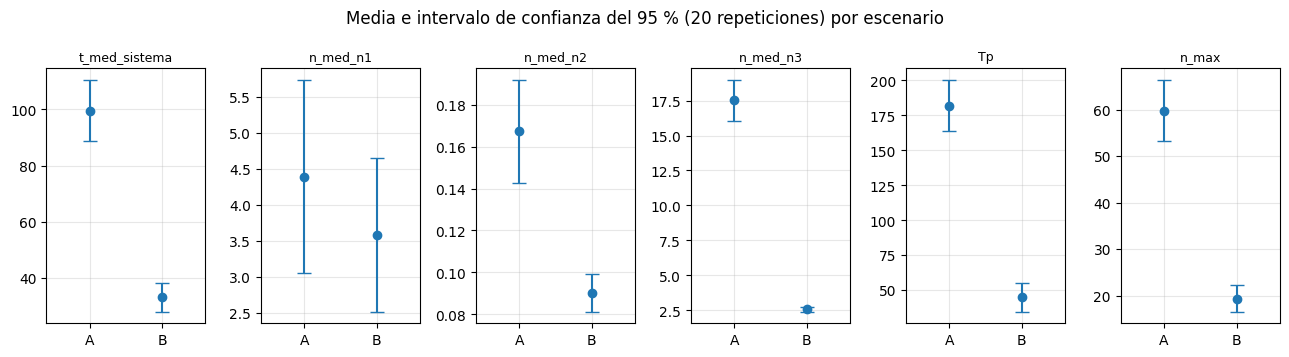

Uniformes consumidas, corrida única A: 780  B: 560


In [6]:
# Figura: medias con IC 95% para las medidas continuas, comparando escenarios
mA, sA, loA, hiA, hA = resumen(repA)
mB, sB, loB, hiB, hB = resumen(repB)
sel = [0, 1, 2, 3, 4, 5]
fig, ax = plt.subplots(1, 6, figsize=(13, 3.6))
for a, j in zip(ax, sel):
    a.errorbar([0, 1], [mA[j], mB[j]], yerr=[hA[j], hB[j]], fmt='o', capsize=5, color='C0')
    a.set_xticks([0, 1]); a.set_xticklabels(['A', 'B']); a.set_xlim(-0.6, 1.6)
    a.set_title(MEDIDAS[j], fontsize=9); a.grid(alpha=0.3)
fig.suptitle('Media e intervalo de confianza del 95 % (20 repeticiones) por escenario')
fig.tight_layout(); fig.savefig('red_ic95.png', dpi=150, bbox_inches='tight'); plt.show()
print("Uniformes consumidas, corrida única A:", gA.consumidos, " B:", gB.consumidos)